In [1]:
import json
import cv2
import matplotlib.pyplot as plt

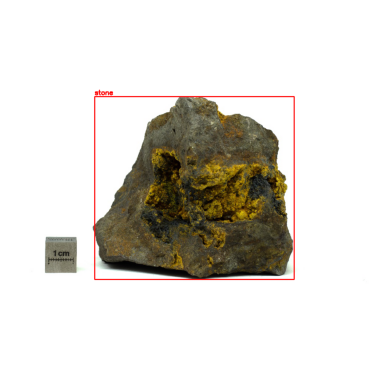

In [2]:
import json
import cv2
import matplotlib.pyplot as plt

# nama file
img_path = "../data/01_raw/mineralimage5k/1_syst/img/1_70018_1_70018.jpg"
json_path = "../data/01_raw/mineralimage5k/1_syst/ann/1_70018_1_70018.jpg.json"

# load gambar
image = cv2.imread(img_path)
if image is None:
    raise FileNotFoundError(f"Gagal load gambar: {img_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# load file json
with open(json_path, "r") as f:
    data = json.load(f)

# ambil bounding box dari struktur DatasetNinja
for obj in data["objects"]:
    label = obj["classTitle"]
    (x1, y1), (x2, y2) = obj["points"]["exterior"]

    # gambar rectangle
    cv2.rectangle(image, (int(x1), int(y1)), (int(x2), int(y2)), (255, 0, 0), 2)
    cv2.putText(image, label, (int(x1), int(y1)-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# tampilkan
plt.imshow(image)
plt.axis("off")
plt.show()
